# Lab 14: One-Way Analysis of Variance

## Comparing Penguin Flipper Length Across Species

This lab uses one-way analysis of variance (ANOVA) to determine whether average flipper length differs among three penguin species: Adelie, Chinstrap, and Gentoo.

The Palmer Penguins dataset contains measurements collected from penguins near Palmer Station in Antarctica. It includes categorical variables such as species, island, and sex, as well as numeric variables such as bill length, bill depth, flipper length, and body mass.

### Variables Used

* **Independent variable:** `species`, a categorical variable with three groups
* **Dependent variable:** `flipper_length_mm`, a continuous numeric variable

### Dataset Source

Palmer Penguins dataset:

https://github.com/allisonhorst/palmerpenguins

CSV version used in this analysis:

https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv


## AI-Assisted Dataset Selection

### AI Prompt

> Help me identify a publicly available dataset suitable for a one-way ANOVA. The dataset must contain a categorical independent variable with at least three groups and a numeric dependent variable. The dataset should also support assumption testing, visualizations, and post-hoc comparisons.

### AI Guidance

The AI recommended the Palmer Penguins dataset because it contains:

1. A categorical variable named `species` with three independent groups: Adelie, Chinstrap, and Gentoo.
2. Several continuous numeric measurements, including flipper length.
3. A sufficient number of observations in each group.
4. Variables that can be easily interpreted using histograms, boxplots, ANOVA, and Tukey’s HSD test.

Based on this guidance, species was selected as the independent variable and flipper length in millimeters was selected as the dependent variable.


## Research Question

**Does mean flipper length differ significantly among Adelie, Chinstrap, and Gentoo penguins?**

### How AI Helped Shape the Research Question

The original idea was to compare a physical characteristic among different groups of penguins. The AI suggested narrowing the analysis to one measurable outcome and one categorical grouping variable. Flipper length was selected because it is numeric, biologically meaningful, and available for all three species.

The final question clearly identifies:

* The population groups being compared
* The numeric measurement being analyzed
* The use of three independent groups, which makes one-way ANOVA appropriate


In [1]:
# Import the required libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Improve the display of tables and charts
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Establish the project folders.
# This code works whether the notebook is opened from the project root
# or from the notebooks folder.

current_directory = Path.cwd()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_directory = project_root / "data"
output_directory = project_root / "outputs"

data_directory.mkdir(parents=True, exist_ok=True)
output_directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data directory: {data_directory}")
print(f"Output directory: {output_directory}")

Project root: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA
Data directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\data
Output directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs


In [3]:
# Load the publicly available Palmer Penguins dataset

dataset_url = (
    "https://raw.githubusercontent.com/"
    "mwaskom/seaborn-data/master/penguins.csv"
)

penguins_raw = pd.read_csv(dataset_url)

# Save a local copy to make the analysis reproducible
local_data_path = data_directory / "penguins.csv"
penguins_raw.to_csv(local_data_path, index=False)

print(f"Dataset downloaded and saved to: {local_data_path}")
print(f"Original dataset shape: {penguins_raw.shape}")

# Display the first 10 observations
penguins_raw.head(10)

Dataset downloaded and saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\data\penguins.csv
Original dataset shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [4]:
# Examine the structure and data types

print("Dataset information:")
print("-" * 50)
penguins_raw.info()

print("\nMissing values by column:")
print("-" * 50)
display(penguins_raw.isna().sum().to_frame(name="Missing_Count"))

print("\nNumber of unique species:")
print(penguins_raw["species"].value_counts())

Dataset information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Missing values by column:
--------------------------------------------------


,Missing_Count
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11



Number of unique species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [5]:
# Retain only the variables required for this ANOVA analysis

anova_data = penguins_raw[
    ["species", "flipper_length_mm"]
].copy()

# Remove observations with missing species or flipper-length values
rows_before_cleaning = len(anova_data)

anova_data = anova_data.dropna(
    subset=["species", "flipper_length_mm"]
).reset_index(drop=True)

rows_after_cleaning = len(anova_data)
rows_removed = rows_before_cleaning - rows_after_cleaning

print(f"Rows before cleaning: {rows_before_cleaning}")
print(f"Rows after cleaning:  {rows_after_cleaning}")
print(f"Rows removed:         {rows_removed}")

print("\nCleaned dataset preview:")
display(anova_data.head(10))

Rows before cleaning: 344
Rows after cleaning:  342
Rows removed:         2

Cleaned dataset preview:


,species,flipper_length_mm
0,Adelie,181.0
1,Adelie,186.0
2,Adelie,195.0
3,Adelie,193.0
4,Adelie,190.0
5,Adelie,181.0
6,Adelie,195.0
7,Adelie,193.0
8,Adelie,190.0
9,Adelie,186.0


In [6]:
# Verify that the variables meet the basic ANOVA requirements

print("Independent variable data type:")
print(anova_data["species"].dtype)

print("\nDependent variable data type:")
print(anova_data["flipper_length_mm"].dtype)

print("\nSpecies included in the analysis:")
print(anova_data["species"].unique())

print("\nNumber of groups:")
print(anova_data["species"].nunique())

Independent variable data type:
object

Dependent variable data type:
float64

Species included in the analysis:
['Adelie' 'Chinstrap' 'Gentoo']

Number of groups:
3


In [7]:
# Calculate descriptive statistics for flipper length by species

group_summary = (
    anova_data
    .groupby("species")["flipper_length_mm"]
    .agg(
        Sample_Size="count",
        Mean="mean",
        Median="median",
        Standard_Deviation="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

group_summary

,Sample_Size,Mean,Median,Standard_Deviation,Minimum,Maximum
species,,,,,,
Adelie,151,189.95,190.0,6.54,172.0,210.0
Chinstrap,68,195.82,196.0,7.13,178.0,212.0
Gentoo,123,217.19,216.0,6.48,203.0,231.0


In [8]:
# Save the descriptive statistics for use in the final report

summary_path = output_directory / "anova_group_summary.csv"
group_summary.to_csv(summary_path)

print(f"Group summary saved to: {summary_path}")
display(group_summary)

Group summary saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\anova_group_summary.csv


,Sample_Size,Mean,Median,Standard_Deviation,Minimum,Maximum
species,,,,,,
Adelie,151,189.95,190.0,6.54,172.0,210.0
Chinstrap,68,195.82,196.0,7.13,178.0,212.0
Gentoo,123,217.19,216.0,6.48,203.0,231.0


## ANOVA Assumptions

A one-way ANOVA generally relies on the following assumptions:

1. **Independence:** Each observation should be independent of the others.
2. **Normality:** The dependent variable should be approximately normally distributed within each group.
3. **Homogeneity of variances:** The variability of the dependent variable should be reasonably similar across groups.
4. **Continuous dependent variable:** Flipper length is measured numerically in millimeters.
5. **Categorical independent variable:** Species contains three independent groups.

### AI Prompt

> What assumptions should be checked before conducting a one-way ANOVA comparing flipper length among three penguin species, and which Python methods and visualizations should be used?

### AI Guidance

The AI recommended:

* Histograms to evaluate the shape of each group’s distribution
* Boxplots to identify differences, spread, and possible outliers
* Q-Q plots to visually assess normality
* Shapiro-Wilk tests as a supporting normality check
* Levene’s test to evaluate equality of variances

The AI also noted that visual evidence should be considered together with formal statistical tests because normality tests can be sensitive to sample size.


In [9]:
# Define the desired species order for consistent charts and tables

species_order = ["Adelie", "Chinstrap", "Gentoo"]

# Create separate arrays for each species group

adelie_flipper = anova_data.loc[
    anova_data["species"] == "Adelie",
    "flipper_length_mm"
]

chinstrap_flipper = anova_data.loc[
    anova_data["species"] == "Chinstrap",
    "flipper_length_mm"
]

gentoo_flipper = anova_data.loc[
    anova_data["species"] == "Gentoo",
    "flipper_length_mm"
]

print("Group sample sizes:")
print(f"Adelie:    {len(adelie_flipper)}")
print(f"Chinstrap: {len(chinstrap_flipper)}")
print(f"Gentoo:    {len(gentoo_flipper)}")

Group sample sizes:
Adelie:    151
Chinstrap: 68
Gentoo:    123


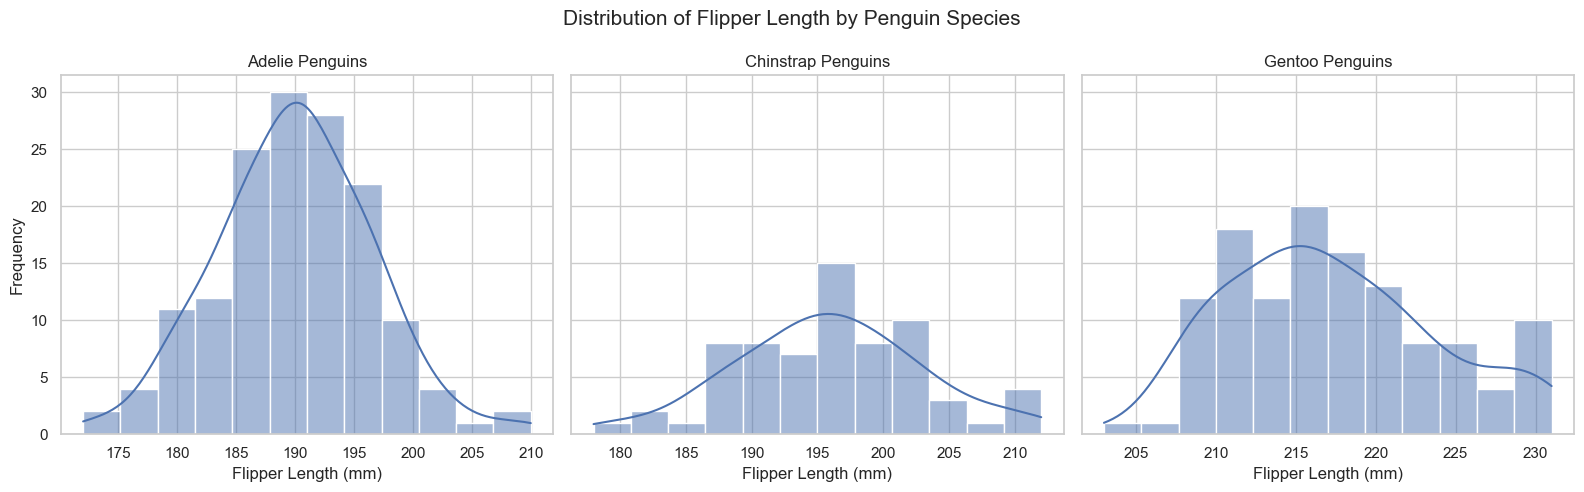

Histogram saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\flipper_length_histograms_by_species.png


In [10]:
# Create histograms to examine the distribution of flipper length
# within each penguin species

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
    sharey=True
)

for axis, species in zip(axes, species_order):
    species_values = anova_data.loc[
        anova_data["species"] == species,
        "flipper_length_mm"
    ]

    sns.histplot(
        species_values,
        bins=12,
        kde=True,
        ax=axis
    )

    axis.set_title(f"{species} Penguins")
    axis.set_xlabel("Flipper Length (mm)")
    axis.set_ylabel("Frequency")

figure.suptitle(
    "Distribution of Flipper Length by Penguin Species",
    fontsize=15
)

plt.tight_layout()

histogram_path = (
    output_directory /
    "flipper_length_histograms_by_species.png"
)

plt.savefig(
    histogram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Histogram saved to: {histogram_path}")

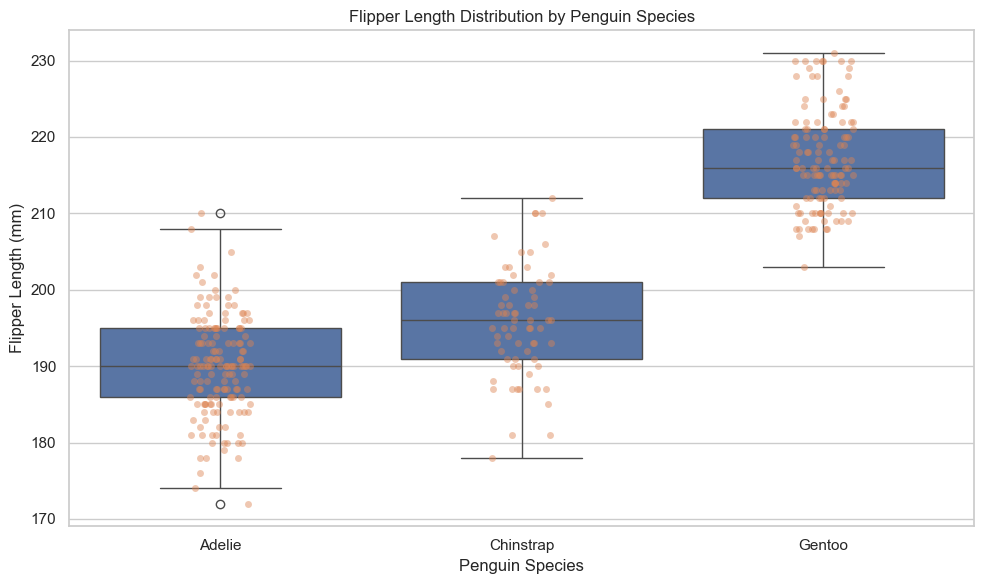

Boxplot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\flipper_length_boxplot_by_species.png


In [11]:
# Create boxplots to examine group differences, variability,
# and potential outliers

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=anova_data,
    x="species",
    y="flipper_length_mm",
    order=species_order
)

sns.stripplot(
    data=anova_data,
    x="species",
    y="flipper_length_mm",
    order=species_order,
    alpha=0.45,
    jitter=True
)

plt.title("Flipper Length Distribution by Penguin Species")
plt.xlabel("Penguin Species")
plt.ylabel("Flipper Length (mm)")

plt.tight_layout()

boxplot_path = (
    output_directory /
    "flipper_length_boxplot_by_species.png"
)

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Boxplot saved to: {boxplot_path}")

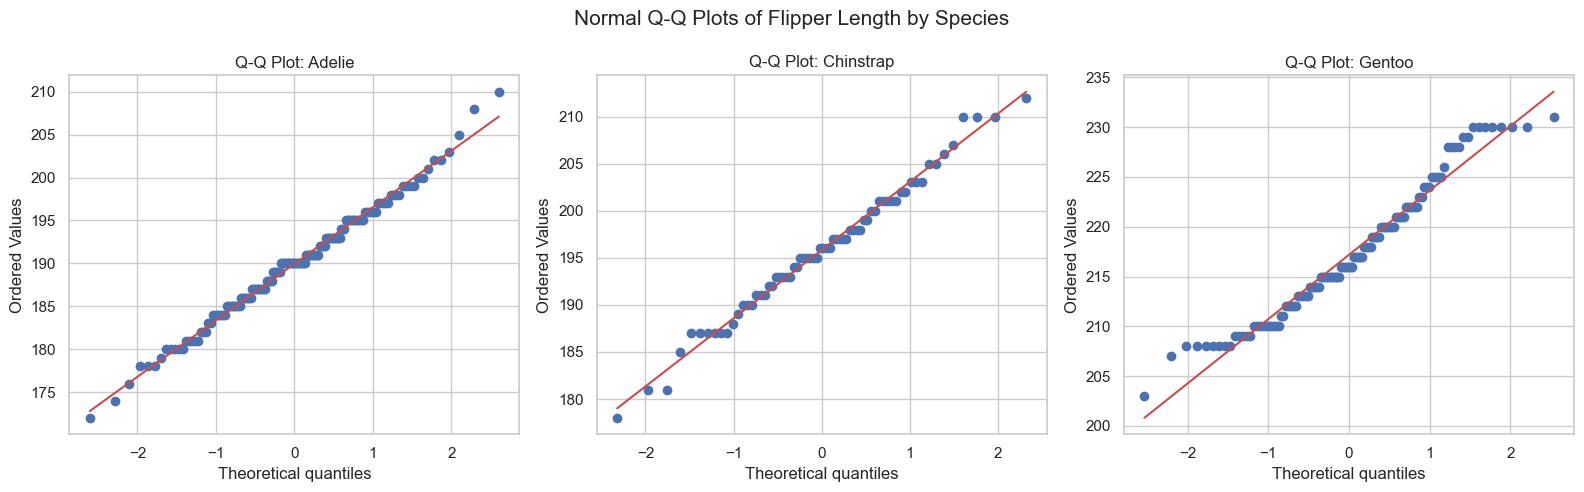

Q-Q plots saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\flipper_length_qq_plots.png


In [12]:
# Create Q-Q plots to visually assess normality within each group

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

for axis, species in zip(axes, species_order):
    species_values = anova_data.loc[
        anova_data["species"] == species,
        "flipper_length_mm"
    ]

    stats.probplot(
        species_values,
        dist="norm",
        plot=axis
    )

    axis.set_title(f"Q-Q Plot: {species}")

figure.suptitle(
    "Normal Q-Q Plots of Flipper Length by Species",
    fontsize=15
)

plt.tight_layout()

qq_plot_path = (
    output_directory /
    "flipper_length_qq_plots.png"
)

plt.savefig(
    qq_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Q-Q plots saved to: {qq_plot_path}")

In [13]:
# Perform Shapiro-Wilk normality tests for each species

normality_results = []

for species in species_order:
    species_values = anova_data.loc[
        anova_data["species"] == species,
        "flipper_length_mm"
    ]

    shapiro_statistic, shapiro_p_value = stats.shapiro(
        species_values
    )

    normality_results.append(
        {
            "Species": species,
            "Sample_Size": len(species_values),
            "Shapiro_Statistic": shapiro_statistic,
            "P_Value": shapiro_p_value,
            "Normality_at_0.05": (
                "Not rejected"
                if shapiro_p_value > 0.05
                else "Rejected"
            )
        }
    )

normality_results_df = pd.DataFrame(normality_results)

normality_results_df[
    ["Shapiro_Statistic", "P_Value"]
] = normality_results_df[
    ["Shapiro_Statistic", "P_Value"]
].round(4)

normality_results_df

,Species,Sample_Size,Shapiro_Statistic,P_Value,Normality_at_0.05
0,Adelie,151,0.9934,0.7200,Not rejected
1,Chinstrap,68,0.9889,0.8106,Not rejected
2,Gentoo,123,0.9622,0.0016,Rejected


### Interpreting the Normality Checks

For each Shapiro-Wilk test:

* **Null hypothesis:** Flipper length follows a normal distribution within the species.
* **Alternative hypothesis:** Flipper length does not follow a normal distribution within the species.
* If the p-value is greater than 0.05, there is insufficient evidence to reject normality.
* If the p-value is less than or equal to 0.05, the test suggests a departure from normality.

The Shapiro-Wilk results should be interpreted together with the histograms and Q-Q plots. Minor departures from normality do not automatically prevent ANOVA, especially when the groups contain a reasonable number of observations and the distributions are not severely skewed.


In [14]:
# Conduct Levene's test for homogeneity of variances

levene_statistic, levene_p_value = levene(
    adelie_flipper,
    chinstrap_flipper,
    gentoo_flipper,
    center="median"
)

print("Levene's Test for Homogeneity of Variances")
print("-" * 50)
print(f"Test statistic: {levene_statistic:.4f}")
print(f"P-value:        {levene_p_value:.6f}")

if levene_p_value > 0.05:
    print(
        "\nConclusion: The p-value is greater than 0.05. "
        "There is insufficient evidence to conclude that the "
        "group variances are different."
    )
    print(
        "The homogeneity-of-variances assumption is considered met."
    )
else:
    print(
        "\nConclusion: The p-value is less than or equal to 0.05. "
        "The group variances appear to be significantly different."
    )
    print(
        "The homogeneity-of-variances assumption may be violated, "
        "so the ANOVA results should be interpreted with caution."
    )

Levene's Test for Homogeneity of Variances
--------------------------------------------------
Test statistic: 0.3306
P-value:        0.718751

Conclusion: The p-value is greater than 0.05. There is insufficient evidence to conclude that the group variances are different.
The homogeneity-of-variances assumption is considered met.


## Research Hypotheses

Let:

* μ₁ represent the mean flipper length of Adelie penguins
* μ₂ represent the mean flipper length of Chinstrap penguins
* μ₃ represent the mean flipper length of Gentoo penguins

### Null Hypothesis

**H₀: μ₁ = μ₂ = μ₃**

The mean flipper length is the same for Adelie, Chinstrap, and Gentoo penguins.

### Alternative Hypothesis

**Hₐ: At least one species mean is different from the others.**

The alternative hypothesis does not initially identify which species differ. If the ANOVA result is statistically significant, Tukey’s HSD post-hoc test will be used to identify the significant pairwise differences.

The significance level for this analysis is:

**α = 0.05**


In [15]:
# Perform the one-way ANOVA

anova_f_statistic, anova_p_value = f_oneway(
    adelie_flipper,
    chinstrap_flipper,
    gentoo_flipper
)

alpha = 0.05

print("One-Way ANOVA Results")
print("-" * 50)
print(f"F-statistic: {anova_f_statistic:.4f}")
print(f"P-value:     {anova_p_value:.10e}")
print(f"Alpha:       {alpha}")

if anova_p_value < alpha:
    print(
        "\nDecision: Reject the null hypothesis."
    )
    print(
        "There is statistically significant evidence that mean "
        "flipper length differs among at least two penguin species."
    )
else:
    print(
        "\nDecision: Fail to reject the null hypothesis."
    )
    print(
        "There is insufficient evidence to conclude that mean "
        "flipper length differs among the penguin species."
    )

One-Way ANOVA Results
--------------------------------------------------
F-statistic: 594.8016
P-value:     1.3517103386e-111
Alpha:       0.05

Decision: Reject the null hypothesis.
There is statistically significant evidence that mean flipper length differs among at least two penguin species.


In [16]:
# Calculate ANOVA degrees of freedom and an effect-size measure

number_of_groups = anova_data["species"].nunique()
total_observations = len(anova_data)

df_between = number_of_groups - 1
df_within = total_observations - number_of_groups

overall_mean = anova_data["flipper_length_mm"].mean()

sum_squares_between = sum(
    len(group["flipper_length_mm"])
    * (
        group["flipper_length_mm"].mean()
        - overall_mean
    ) ** 2
    for _, group in anova_data.groupby("species")
)

sum_squares_total = (
    (
        anova_data["flipper_length_mm"]
        - overall_mean
    ) ** 2
).sum()

eta_squared = sum_squares_between / sum_squares_total

print("Additional ANOVA Information")
print("-" * 50)
print(f"Degrees of freedom between groups: {df_between}")
print(f"Degrees of freedom within groups:  {df_within}")
print(f"Eta-squared effect size:            {eta_squared:.4f}")

if eta_squared < 0.01:
    effect_interpretation = "negligible"
elif eta_squared < 0.06:
    effect_interpretation = "small"
elif eta_squared < 0.14:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(
    f"Effect-size interpretation: {effect_interpretation}"
)

Additional ANOVA Information
--------------------------------------------------
Degrees of freedom between groups: 2
Degrees of freedom within groups:  339
Eta-squared effect size:            0.7782
Effect-size interpretation: large


## AI-Assisted Interpretation of the ANOVA

### AI Prompt

> Help me interpret the F-statistic and p-value from a one-way ANOVA comparing mean flipper length among Adelie, Chinstrap, and Gentoo penguins. Explain the result in the context of the research question without claiming that ANOVA identifies the specific groups that differ.

### Interpretation Guidance

The F-statistic compares variation between the species means with variation among observations within each species. A relatively large F-statistic suggests that differences among the group means are large compared with ordinary within-group variation.

If the ANOVA p-value is below 0.05, the null hypothesis is rejected. This means that the observed differences in average flipper length would be unlikely if all three penguin species truly had the same population mean.

A significant ANOVA result establishes that at least one species mean differs, but it does not identify the specific species pairs responsible for the difference. Therefore, Tukey’s HSD test is needed for pairwise comparisons.


## Tukey’s HSD Post-Hoc Test

A statistically significant ANOVA indicates that at least one group mean differs, but it does not identify which specific species differ from one another.

Because the ANOVA result was evaluated at a significance level of 0.05, Tukey’s Honestly Significant Difference test is used as a post-hoc analysis when the ANOVA p-value is below 0.05.

Tukey’s HSD compares all possible pairs while controlling the overall family-wise Type I error rate.

The pairwise comparisons are:

1. Adelie versus Chinstrap
2. Adelie versus Gentoo
3. Chinstrap versus Gentoo


In [17]:
# Perform Tukey's HSD post-hoc test when the ANOVA is significant

tukey_result = None
tukey_results_df = pd.DataFrame()

if anova_p_value < alpha:
    tukey_result = pairwise_tukeyhsd(
        endog=anova_data["flipper_length_mm"],
        groups=anova_data["species"],
        alpha=alpha
    )

    print("Tukey's HSD Pairwise Comparison Results")
    print("-" * 70)
    print(tukey_result)

    # Convert the Tukey results table into a DataFrame
    tukey_results_df = pd.DataFrame(
        data=tukey_result.summary().data[1:],
        columns=tukey_result.summary().data[0]
    )

    # Convert numeric columns from objects to numeric values
    numeric_columns = [
        "meandiff",
        "p-adj",
        "lower",
        "upper"
    ]

    for column in numeric_columns:
        tukey_results_df[column] = pd.to_numeric(
            tukey_results_df[column]
        )

    # Save the Tukey results
    tukey_output_path = (
        output_directory /
        "tukey_hsd_pairwise_results.csv"
    )

    tukey_results_df.to_csv(
        tukey_output_path,
        index=False
    )

    print(
        f"\nTukey results saved to: "
        f"{tukey_output_path}"
    )

    display(tukey_results_df)

else:
    print(
        "The ANOVA result was not statistically significant. "
        "Therefore, Tukey's HSD test was not required."
    )

Tukey's HSD Pairwise Comparison Results
----------------------------------------------------------------------
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj  lower   upper  reject
---------------------------------------------------------
   Adelie Chinstrap   5.8699   0.0  3.5866  8.1532   True
   Adelie    Gentoo  27.2333   0.0 25.3344 29.1323   True
Chinstrap    Gentoo  21.3635   0.0 19.0008 23.7261   True
---------------------------------------------------------

Tukey results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\tukey_hsd_pairwise_results.csv


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Adelie,Chinstrap,5.8699,0.0,3.5866,8.1532,True
1,Adelie,Gentoo,27.2333,0.0,25.3344,29.1323,True
2,Chinstrap,Gentoo,21.3635,0.0,19.0008,23.7261,True


In [18]:
# Generate plain-language interpretations of the Tukey comparisons

pairwise_interpretations = []

if not tukey_results_df.empty:
    species_means = (
        anova_data
        .groupby("species")["flipper_length_mm"]
        .mean()
    )

    significant_comparisons = tukey_results_df[
        tukey_results_df["reject"].astype(bool)
    ]

    print("Interpretation of Significant Pairwise Differences")
    print("-" * 70)

    if significant_comparisons.empty:
        print(
            "None of the Tukey pairwise comparisons were "
            "statistically significant."
        )
    else:
        for _, row in significant_comparisons.iterrows():
            group_1 = row["group1"]
            group_2 = row["group2"]

            group_1_mean = species_means[group_1]
            group_2_mean = species_means[group_2]

            if group_1_mean > group_2_mean:
                higher_group = group_1
                lower_group = group_2
            else:
                higher_group = group_2
                lower_group = group_1

            interpretation = (
                f"{higher_group} penguins have a significantly "
                f"higher mean flipper length than {lower_group} "
                f"penguins (adjusted p-value = "
                f"{row['p-adj']:.6f})."
            )

            pairwise_interpretations.append(
                interpretation
            )

            print(f"• {interpretation}")

else:
    print(
        "No Tukey interpretation was produced because "
        "post-hoc testing was not required."
    )

Interpretation of Significant Pairwise Differences
----------------------------------------------------------------------
• Chinstrap penguins have a significantly higher mean flipper length than Adelie penguins (adjusted p-value = 0.000000).
• Gentoo penguins have a significantly higher mean flipper length than Adelie penguins (adjusted p-value = 0.000000).
• Gentoo penguins have a significantly higher mean flipper length than Chinstrap penguins (adjusted p-value = 0.000000).


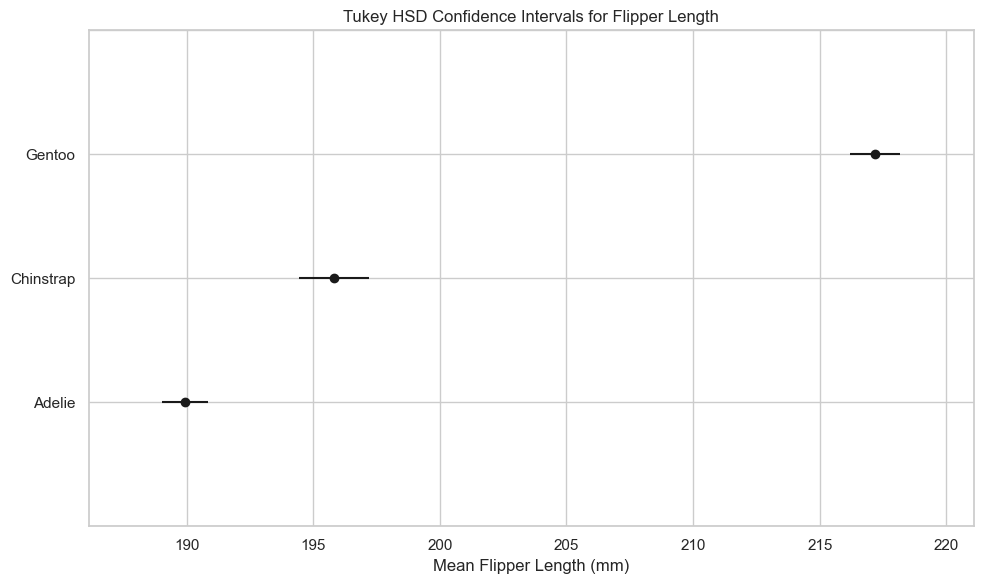

Tukey confidence interval plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\tukey_hsd_confidence_intervals.png


In [19]:
# Visualize the Tukey simultaneous confidence intervals

if tukey_result is not None:
    tukey_figure = tukey_result.plot_simultaneous(
        figsize=(10, 6)
    )

    plt.title(
        "Tukey HSD Confidence Intervals for Flipper Length"
    )
    plt.xlabel("Mean Flipper Length (mm)")
    plt.tight_layout()

    tukey_plot_path = (
        output_directory /
        "tukey_hsd_confidence_intervals.png"
    )

    tukey_figure.savefig(
        tukey_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Tukey confidence interval plot saved to: "
        f"{tukey_plot_path}"
    )
else:
    print(
        "Tukey confidence interval plot was not created "
        "because post-hoc testing was not required."
    )

In [20]:
# Calculate group means and 95% confidence intervals

group_mean_plot_df = (
    anova_data
    .groupby("species")["flipper_length_mm"]
    .agg(
        Sample_Size="count",
        Mean="mean",
        Standard_Deviation="std",
        Standard_Error="sem"
    )
    .reindex(species_order)
)

# Calculate the critical t-value separately for each group
group_mean_plot_df["T_Critical"] = (
    group_mean_plot_df["Sample_Size"]
    .apply(
        lambda sample_size: stats.t.ppf(
            0.975,
            df=sample_size - 1
        )
    )
)

group_mean_plot_df["Margin_of_Error"] = (
    group_mean_plot_df["T_Critical"]
    * group_mean_plot_df["Standard_Error"]
)

group_mean_plot_df["CI_Lower"] = (
    group_mean_plot_df["Mean"]
    - group_mean_plot_df["Margin_of_Error"]
)

group_mean_plot_df["CI_Upper"] = (
    group_mean_plot_df["Mean"]
    + group_mean_plot_df["Margin_of_Error"]
)

group_mean_plot_df = group_mean_plot_df.round(3)

display(group_mean_plot_df)

,Sample_Size,Mean,Standard_Deviation,Standard_Error,T_Critical,Margin_of_Error,CI_Lower,CI_Upper
species,,,,,,,,
Adelie,151,189.954,6.539,0.532,1.976,1.052,188.902,191.005
Chinstrap,68,195.824,7.132,0.865,1.996,1.726,194.097,197.550
Gentoo,123,217.187,6.485,0.585,1.980,1.158,216.029,218.345


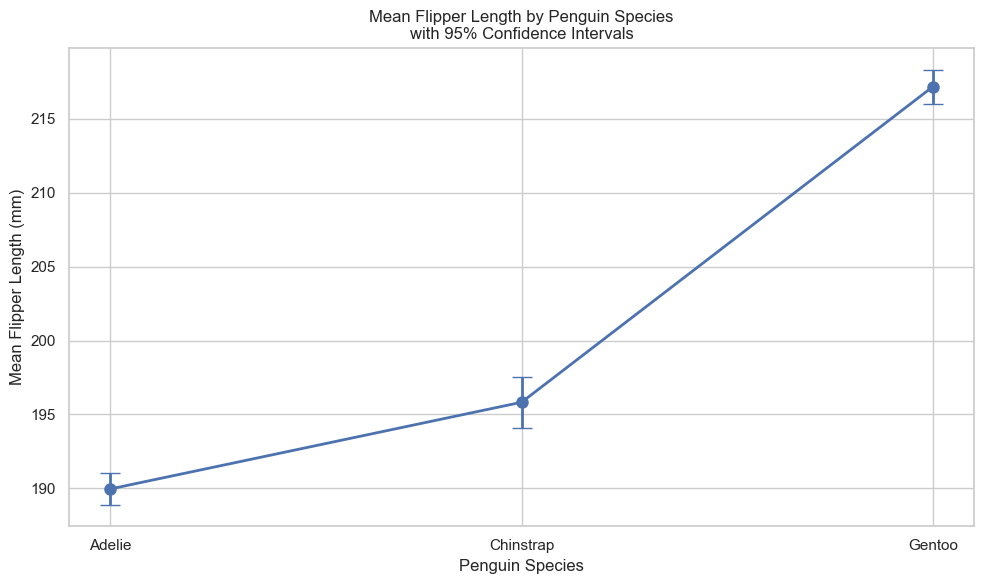

Group mean plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\mean_flipper_length_with_95_ci.png


In [21]:
# Create a group mean plot with 95% confidence intervals

x_positions = np.arange(
    len(group_mean_plot_df)
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=x_positions,
    y=group_mean_plot_df["Mean"],
    yerr=group_mean_plot_df["Margin_of_Error"],
    fmt="o-",
    capsize=7,
    linewidth=2,
    markersize=8
)

plt.xticks(
    ticks=x_positions,
    labels=group_mean_plot_df.index
)

plt.title(
    "Mean Flipper Length by Penguin Species\n"
    "with 95% Confidence Intervals"
)
plt.xlabel("Penguin Species")
plt.ylabel("Mean Flipper Length (mm)")

plt.tight_layout()

mean_plot_path = (
    output_directory /
    "mean_flipper_length_with_95_ci.png"
)

plt.savefig(
    mean_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Group mean plot saved to: {mean_plot_path}"
)

In [22]:
# Save the group mean and confidence interval statistics

mean_summary_path = (
    output_directory /
    "group_mean_confidence_intervals.csv"
)

group_mean_plot_df.to_csv(
    mean_summary_path
)

print(
    f"Mean confidence interval table saved to: "
    f"{mean_summary_path}"
)

Mean confidence interval table saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\group_mean_confidence_intervals.csv


In [23]:
# Create and save the main ANOVA results table

anova_results_df = pd.DataFrame(
    {
        "Test": [
            "Levene's Test",
            "One-Way ANOVA"
        ],
        "Statistic": [
            levene_statistic,
            anova_f_statistic
        ],
        "P_Value": [
            levene_p_value,
            anova_p_value
        ],
        "Alpha": [
            alpha,
            alpha
        ],
        "Decision": [
            (
                "Homogeneity not rejected"
                if levene_p_value > alpha
                else "Homogeneity rejected"
            ),
            (
                "Reject null hypothesis"
                if anova_p_value < alpha
                else "Fail to reject null hypothesis"
            )
        ]
    }
)

anova_results_df["Statistic"] = (
    anova_results_df["Statistic"].round(4)
)

anova_results_df["P_Value"] = (
    anova_results_df["P_Value"].map(
        lambda value: f"{value:.10e}"
    )
)

anova_results_path = (
    output_directory /
    "anova_test_results.csv"
)

anova_results_df.to_csv(
    anova_results_path,
    index=False
)

normality_results_path = (
    output_directory /
    "shapiro_normality_results.csv"
)

normality_results_df.to_csv(
    normality_results_path,
    index=False
)

print(
    f"ANOVA results saved to: "
    f"{anova_results_path}"
)

print(
    f"Normality results saved to: "
    f"{normality_results_path}"
)

display(anova_results_df)

ANOVA results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\anova_test_results.csv
Normality results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\shapiro_normality_results.csv


,Test,Statistic,P_Value,Alpha,Decision
0,Levene's Test,0.3306,7.1875107855e-01,0.05,Homogeneity not rejected
1,One-Way ANOVA,594.8016,1.3517103386e-111,0.05,Reject null hypothesis


In [24]:
# Generate a final narrative summary from the statistical results

from IPython.display import Markdown, display

species_mean_text = "\n".join(
    [
        (
            f"- **{species}:** "
            f"{group_mean_plot_df.loc[species, 'Mean']:.2f} mm "
            f"(n = "
            f"{int(group_mean_plot_df.loc[species, 'Sample_Size'])})"
        )
        for species in species_order
    ]
)

non_normal_groups = normality_results_df.loc[
    normality_results_df["P_Value"] <= alpha,
    "Species"
].tolist()

if len(non_normal_groups) == 0:
    normality_interpretation = (
        "The Shapiro-Wilk tests did not provide significant "
        "evidence against normality for any species."
    )
else:
    normality_interpretation = (
        "The Shapiro-Wilk tests suggested departures from "
        "normality for "
        + ", ".join(non_normal_groups)
        + ". However, the histograms and Q-Q plots were also "
        "reviewed because formal normality tests can be sensitive "
        "to sample size."
    )

if levene_p_value > alpha:
    variance_interpretation = (
        "Levene's test was not statistically significant "
        f"(p = {levene_p_value:.4f}), so the equality-of-variances "
        "assumption was considered reasonable."
    )
else:
    variance_interpretation = (
        "Levene's test was statistically significant "
        f"(p = {levene_p_value:.4f}), suggesting that the "
        "group variances may not be equal. The ANOVA results "
        "should therefore be interpreted with some caution."
    )

if anova_p_value < alpha:
    anova_interpretation = (
        "The one-way ANOVA was statistically significant, "
        f"F({df_between}, {df_within}) = "
        f"{anova_f_statistic:.2f}, "
        f"p = {anova_p_value:.3e}. The null hypothesis was "
        "rejected. Mean flipper length differs among at least "
        "two of the three penguin species."
    )
else:
    anova_interpretation = (
        "The one-way ANOVA was not statistically significant, "
        f"F({df_between}, {df_within}) = "
        f"{anova_f_statistic:.2f}, "
        f"p = {anova_p_value:.4f}. The analysis failed to reject "
        "the null hypothesis."
    )

if pairwise_interpretations:
    tukey_interpretation = " ".join(
        pairwise_interpretations
    )
elif anova_p_value < alpha:
    tukey_interpretation = (
        "Tukey's HSD did not identify any statistically "
        "significant pairwise comparisons."
    )
else:
    tukey_interpretation = (
        "Post-hoc testing was not required because the ANOVA "
        "result was not statistically significant."
    )

final_summary = f"""
# Final Summary

## Overview of the Dataset and Research Question

This analysis used the Palmer Penguins dataset to investigate
whether mean flipper length differs among Adelie, Chinstrap, and
Gentoo penguins. Species was the categorical independent variable,
and flipper length measured in millimeters was the numeric dependent
variable.

The group means were:

{species_mean_text}

The research question was: **Does mean flipper length differ
significantly among Adelie, Chinstrap, and Gentoo penguins?**

## Methodology and AI Support

An AI tool assisted with selecting an appropriate dataset, identifying
the independent and dependent variables, developing the research
question, and determining the assumptions that should be evaluated.
The AI recommended using histograms, boxplots, Q-Q plots, Shapiro-Wilk
tests, and Levene's test before conducting the one-way ANOVA.

The null hypothesis stated that all three population means were equal.
The alternative hypothesis stated that at least one species mean was
different. The significance level was set at 0.05.

## Assumption Checks

{normality_interpretation}

{variance_interpretation}

Independence was considered reasonable because each row represented
a separate penguin observation.

## ANOVA Results and Interpretation

{anova_interpretation}

The eta-squared value was **{eta_squared:.4f}**, indicating a
**{effect_interpretation}** effect. This represents the proportion
of total variation in flipper length associated with penguin species.

## Post-Hoc Findings

{tukey_interpretation}

## Conclusion

The analysis demonstrates how one-way ANOVA can compare the means of
a numeric measurement across three or more independent groups. The
boxplot, group mean plot, confidence intervals, ANOVA results, and
Tukey comparisons provide complementary evidence for understanding
how penguin flipper lengths vary among species.
"""

display(Markdown(final_summary))

# Save the generated summary as a Markdown file
summary_file_path = (
    output_directory /
    "lab14_anova_final_summary.md"
)

summary_file_path.write_text(
    final_summary,
    encoding="utf-8"
)

print(
    f"\nFinal summary saved to: "
    f"{summary_file_path}"
)


# Final Summary

## Overview of the Dataset and Research Question

This analysis used the Palmer Penguins dataset to investigate
whether mean flipper length differs among Adelie, Chinstrap, and
Gentoo penguins. Species was the categorical independent variable,
and flipper length measured in millimeters was the numeric dependent
variable.

The group means were:

- **Adelie:** 189.95 mm (n = 151)
- **Chinstrap:** 195.82 mm (n = 68)
- **Gentoo:** 217.19 mm (n = 123)

The research question was: **Does mean flipper length differ
significantly among Adelie, Chinstrap, and Gentoo penguins?**

## Methodology and AI Support

An AI tool assisted with selecting an appropriate dataset, identifying
the independent and dependent variables, developing the research
question, and determining the assumptions that should be evaluated.
The AI recommended using histograms, boxplots, Q-Q plots, Shapiro-Wilk
tests, and Levene's test before conducting the one-way ANOVA.

The null hypothesis stated that all three population means were equal.
The alternative hypothesis stated that at least one species mean was
different. The significance level was set at 0.05.

## Assumption Checks

The Shapiro-Wilk tests suggested departures from normality for Gentoo. However, the histograms and Q-Q plots were also reviewed because formal normality tests can be sensitive to sample size.

Levene's test was not statistically significant (p = 0.7188), so the equality-of-variances assumption was considered reasonable.

Independence was considered reasonable because each row represented
a separate penguin observation.

## ANOVA Results and Interpretation

The one-way ANOVA was statistically significant, F(2, 339) = 594.80, p = 1.352e-111. The null hypothesis was rejected. Mean flipper length differs among at least two of the three penguin species.

The eta-squared value was **0.7782**, indicating a
**large** effect. This represents the proportion
of total variation in flipper length associated with penguin species.

## Post-Hoc Findings

Chinstrap penguins have a significantly higher mean flipper length than Adelie penguins (adjusted p-value = 0.000000). Gentoo penguins have a significantly higher mean flipper length than Adelie penguins (adjusted p-value = 0.000000). Gentoo penguins have a significantly higher mean flipper length than Chinstrap penguins (adjusted p-value = 0.000000).

## Conclusion

The analysis demonstrates how one-way ANOVA can compare the means of
a numeric measurement across three or more independent groups. The
boxplot, group mean plot, confidence intervals, ANOVA results, and
Tukey comparisons provide complementary evidence for understanding
how penguin flipper lengths vary among species.



Final summary saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_14_ANOVA\outputs\lab14_anova_final_summary.md


In [25]:
# Display a list of all files created in the outputs folder

print("Files created for Lab 14:")
print("-" * 60)

for output_file in sorted(output_directory.iterdir()):
    if output_file.is_file():
        print(f"• {output_file.name}")

Files created for Lab 14:
------------------------------------------------------------
• anova_group_summary.csv
• anova_test_results.csv
• flipper_length_boxplot_by_species.png
• flipper_length_histograms_by_species.png
• flipper_length_qq_plots.png
• group_mean_confidence_intervals.csv
• lab14_anova_final_summary.md
• mean_flipper_length_with_95_ci.png
• Screenshot 2026-06-24 224936.png
• shapiro_normality_results.csv
• tukey_hsd_confidence_intervals.png
• tukey_hsd_pairwise_results.csv
